# AI Evals

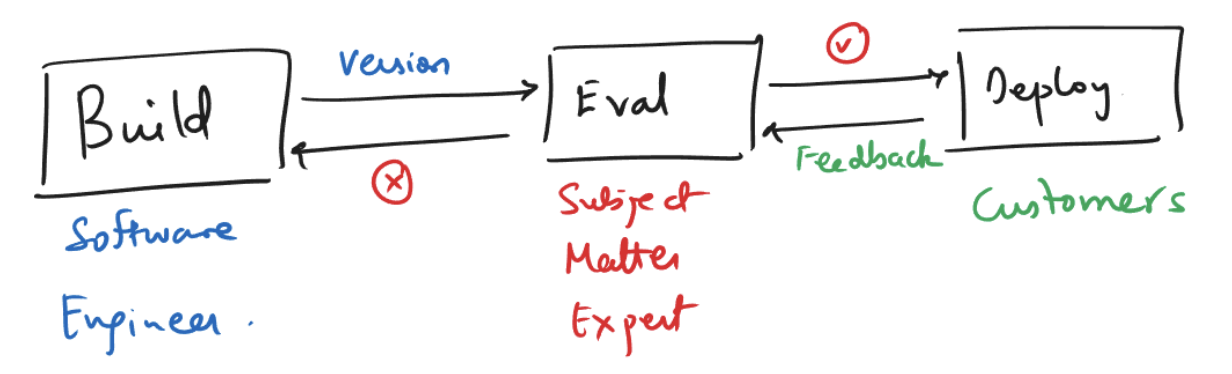

## 1. Install Dependencies

In [ ]:
!pip install openai deepeval faiss-cpu numpy pandas matplotlib pymupdf tiktoken --quiet
print("All packages installed!")

## 2. Imports & API Key Setup

In [ ]:
import os
import re
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
import warnings
warnings.filterwarnings('ignore')

from openai import OpenAI
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
client = OpenAI()
print("OpenAI client ready!")

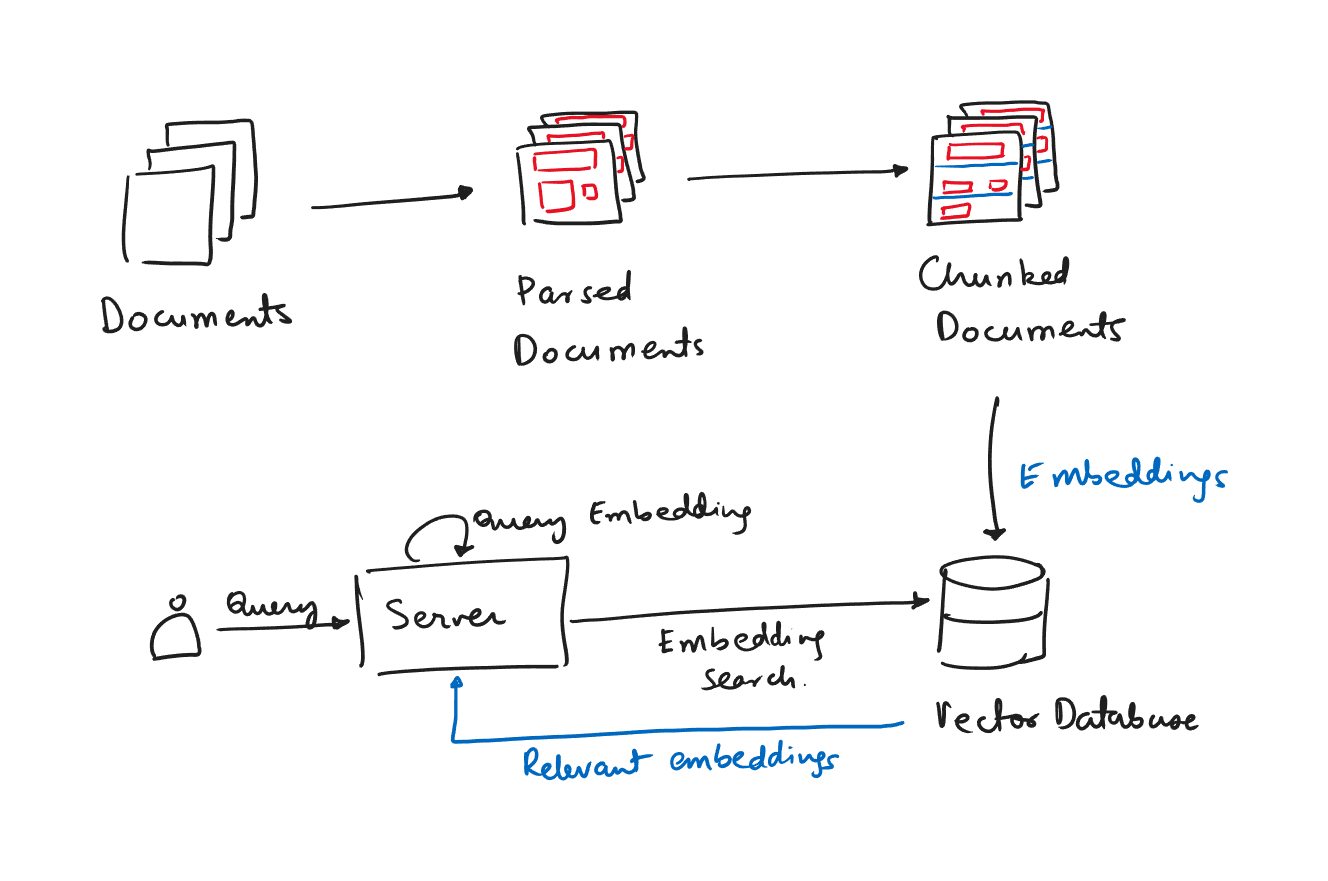

## Setup

In [ ]:
!pip install -qU langchain langchain-classic langchain-community langchain-core \
    langchain-text-splitters langchain-huggingface langchain-ollama \
    faiss-cpu sentence-transformers pypdf cohere

# RAG on Research Papers

| # | Paper |
|---|-------|
| 1 | Attention Is All You Need |
| 2 | BERT |
| 3 | Chain-of-Thought Prompting |
| 4 | Constitutional AI |
| 5 | GPT-3 |
| 6 | LLaMA 2 |
| 7 | LoRA |
| 8 | Mixtral of Experts |
| 9 | RAG (Lewis et al.) |
| 10 | Self-RAG |

In [ ]:
import urllib.request
from pathlib import Path

PAPERS_DIR = Path('ai_papers')
PAPERS_DIR.mkdir(exist_ok=True)

PAPERS_META = [
    {'title': 'Attention Is All You Need', 'arxiv_id': '1706.03762'},
    {'title': 'BERT',                      'arxiv_id': '1810.04805'},
    {'title': 'Chain-of-Thought Prompting','arxiv_id': '2201.11903'},
    {'title': 'Constitutional AI',         'arxiv_id': '2212.08073'},
    {'title': 'GPT-3',                     'arxiv_id': '2005.14165'},
    {'title': 'LLaMA 2',                   'arxiv_id': '2307.09288'},
    {'title': 'LoRA',                      'arxiv_id': '2106.09685'},
    {'title': 'Mixtral of Experts',        'arxiv_id': '2401.04088'},
    {'title': 'RAG (Lewis et al.)',        'arxiv_id': '2005.11401'},
    {'title': 'Self-RAG',                  'arxiv_id': '2310.11511'},
]

papers = []
print(f'{"#":>3}  {"arxiv ID":<14}  Title')
print('─' * 70)

for i, meta in enumerate(PAPERS_META):
    pdf_path = PAPERS_DIR / f'paper_{i+1:02d}_{meta["arxiv_id"]}.pdf'

    if not (pdf_path.exists() and pdf_path.stat().st_size > 10_000):
        try:
            url = f'https://arxiv.org/pdf/{meta["arxiv_id"]}.pdf'
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req, timeout=60) as resp, \
                 open(pdf_path, 'wb') as f:
                f.write(resp.read())
        except Exception as e:
            print(f'{i+1:>3}  {meta["arxiv_id"]:<14}{meta["title"]} -- {e}')
            papers.append({**meta, 'path': None})
            continue

    print(f'{i+1:>3}  {meta["arxiv_id"]:<14}  {meta["title"]}')
    papers.append({**meta, 'path': str(pdf_path)})

print(f'\n{sum(p["path"] is not None for p in papers)}/10 papers ready in ./{PAPERS_DIR}/')

## Custom Chunking · Section-Based

Research papers are structured like `1. Introduction`, `2. Background`, `3.1 Method`.

This is the custom chunking strategy covered in [RAG Chunking Strategies](https://colab.research.google.com/drive/1T9jpMPupUMwxvgcirDUMJ3Vk3msFZ4BV?usp=sharing#scrollTo=5979a00b).

In [ ]:
def section_chunks(text, max_top=12):
    pattern = re.compile(
        r"(?<=\s)"
        r"(\d+(?:\.\d+){0,2})"
        r"\s+([A-Z][a-z][a-zA-Z\-' ]{1,50})"
    )
    blacklist = re.compile(
        r'^(Figure|Table|Equation|Section|Algorithm|Appendix|Input|Output|'
        r'Residual|Label|Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec|Proceedings)\b'
    )
    parse_num = lambda s: tuple(int(x) for x in s.split('.'))

    candidates = []
    for m in pattern.finditer(text):
        num_s, title = m.group(1), m.group(2).strip()
        if blacklist.match(title):
            continue
        num = parse_num(num_s)
        if not (1 <= num[0] <= max_top):
            continue
        candidates.append((m.start(), num, f'{num_s} {title[:45]}'))

    kept, prev = [], (0,)
    for pos, num, label in candidates:
        if num > prev:
            kept.append((pos, label))
            prev = num

    if not kept:
        return [(0, len(text), 'full_doc')]

    spans = []
    if kept[0][0] > 0:
        spans.append((0, kept[0][0], 'preamble'))
    for i, (pos, name) in enumerate(kept):
        end = kept[i + 1][0] if i + 1 < len(kept) else len(text)
        spans.append((pos, end, name))
    return spans


In [ ]:
import os, shutil, glob

for path in glob.glob('/usr/local/lib/python3.12/dist-packages/fitz*'):
    print('removing', path)
    if os.path.isdir(path):
        shutil.rmtree(path)
    else:
        os.remove(path)

!pip install --force-reinstall --no-deps pymupdf

In [ ]:
import pymupdf
print(pymupdf.__version__)
print(pymupdf.open)  # sanity check: should print <built-in function open> or similar

results = []
for p in papers:
    if p['path'] is None:
        continue
    doc  = pymupdf.open(p['path'])
    text = ''.join(page.get_text() for page in doc)
    doc.close()
    spans = section_chunks(text)
    results.append({'title': p['title'], 'chunks': len(spans)})

col1 = max(len(r['title']) for r in results)
print(f'  {"Paper":<{col1}}  Chunks')
print('─' * (col1 + 12))
for r in results:
    print(f'  {r["title"]:<{col1}}  {r["chunks"]}')

Embed & Index with FAISS

Each paper is split into section-based chunks and embedded using [`all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2), a lightweight sentence-transformer that produces 384-dimensional vectors.

The embeddings are stored in a [FAISS](https://github.com/facebookresearch/faiss) vector index — an efficient similarity search library by Meta. At query time, the retriever returns the **3 most semantically similar chunks** across all 10 papers.

In [ ]:
import subprocess, sys

def pip(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

pip('langchain')
pip('langchain-community')
pip('langchain-huggingface')
pip('faiss-cpu')
pip('sentence-transformers')

import os
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

docs = []
for p in papers:
    if p['path'] is None:
        continue
    doc  = pymupdf.open(p['path'])
    text = ''.join(page.get_text() for page in doc)
    doc.close()
    spans = section_chunks(text)
    for s, e, name in spans:
        chunk_text = text[s:e].strip()
        if chunk_text:
            docs.append(Document(
                page_content=chunk_text,
                metadata={'paper': p['title'], 'section': name, 'arxiv_id': p['arxiv_id']}
            ))

vectorstore = FAISS.from_documents(docs, embedding_model)
retriever   = vectorstore.as_retriever(search_kwargs={'k': 3})

print(f'Indexed {len(docs)} chunks across {len(papers)} papers')

## Test Queries

10 queries covering each of the 10 papers. Each query targets a core concept from its paper — used in the next cell to evaluate retrieval and answer quality.

These 10 queries act as a **golden Queries** — a curated set of questions, used as the benchmark for evaluation. For simplicity we use one query per paper here, but in practice a robust golden dataset would contain 10 or more questions per paper, covering factual, conceptual, comparative, and applied aspects.

In [ ]:
TEST_QUERIES = [
    "How does the attention mechanism work in Transformers?",
    "What is the BERT pre-training objective?",
    "How does chain-of-thought prompting improve reasoning?",
    "What are the core principles of Constitutional AI?",
    "What are the few-shot learning capabilities of GPT-3?",
    "How does LLaMA 2 handle safety and alignment?",
    "How does LoRA reduce the number of trainable parameters?",
    "How does Mixtral use sparse mixture of experts?",
    "How does RAG combine retrieval with generation?",
    "What is the self-reflection mechanism in Self-RAG?",
]

print(f'{"#":>3}  Query')
print('─' * 80)
for i, q in enumerate(TEST_QUERIES):
    print(f'{i:>3}  {q}')

## Build Evaluation Dataset

Runs all 10 test queries through the RAG pipeline and stores the results in a structured CSV file — one row per query.

Each row captures the query, the top-3 retrieved chunks (with paper and section metadata), and the GPT-4o generated answer. This CSV becomes the base for all subsequent evaluation cells.

In [ ]:
import csv

from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get('OPENAI_API_KEY'))

CSV_PATH = 'rag_eval.csv'

fieldnames = [
    'query',
    'context_1', 'context_2', 'context_3',
    'answer',
]

rows = []
for i, query in enumerate(TEST_QUERIES):
    print(f'[{i+1:02d}/10] {query[:70]}')
    retrieved = retriever.invoke(query)

    context_cols = {}
    context_parts = []
    for j, doc in enumerate(retrieved):
        label = f'context_{j+1}'
        chunk = f'[{doc.metadata["paper"]} — {doc.metadata["section"]}]\n{doc.page_content}'
        context_cols[label] = chunk
        context_parts.append(chunk)

    context = '\n\n'.join(context_parts)

    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[
            {'role': 'system', 'content': (
                'You are a research assistant. Answer the question using only '
                'the provided context. Be concise and precise.'
            )},
            {'role': 'user', 'content': f'Context:\n{context}\n\nQuestion: {query}'}
        ]
    )
    answer = response.choices[0].message.content

    rows.append({'query': query, **context_cols, 'answer': answer})

with open(CSV_PATH, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print(f'\nSaved {len(rows)} rows to {CSV_PATH}')

import pandas as pd

pd.set_option('display.max_colwidth', 60)
df = pd.read_csv(CSV_PATH)
df.head(10)

## Human Annotation

Before running any automated metrics, we collect human judgements on each answer. These columns are left blank intentionally — fill each row with a score from **1 to 5** and a short reason explaining the judgement.

Human annotation serves as the ground truth against which automated evaluation metrics (answer relevancy, contextual relevancy, faithfulness) are later compared. This is a critical step in any RAG evaluation pipeline — automated metrics alone can be misleading without a human baseline to validate against.

| Score | Meaning |
|-------|---------|
| 1 | Completely wrong or irrelevant |
| 2 | Partially addresses the query |
| 3 | Adequate but missing key points |
| 4 | Good answer with minor gaps |
| 5 | Perfect — complete and accurate |

After filling the scores and reasons, re-run this cell to save them back to the CSV.

In [ ]:
import pandas as pd

CSV_PATH = 'rag_eval.csv'

df = pd.read_csv(CSV_PATH)

if 'human_label_score' not in df.columns:
    df['human_label_score']  = ''
    df['human_label_reason'] = ''
    df.to_csv(CSV_PATH, index=False)
    print('human_label_score and human_label_reason columns added.')
    print('Open the CSV, fill in scores (1-5) and reasons, then re-run this cell.')
else:
    score_filled  = df['human_label_score'].notna()  & (df['human_label_score']  != '')
    reason_filled = df['human_label_reason'].notna() & (df['human_label_reason'] != '')
    print(f'Scores  annotated : {score_filled.sum()}/10')
    print(f'Reasons annotated : {reason_filled.sum()}/10')
    df.to_csv(CSV_PATH, index=False)

pd.set_option('display.max_colwidth', 60)
df.head(10)

## Evaluation Summary

In a production RAG evaluation pipeline, human annotation does not scale. The standard approach is:

1. **Generate synthetic queries** — for each research paper, an LLM generates 20 to 50 diverse questions covering different aspects: factual, conceptual, comparative, and applied. This gives a larger, broader evaluation set.
2. **LLM-as-judge** — instead of human annotators, a capable LLM (GPT-4o) scores each answer automatically across multiple dimensions using DeepEval's built-in metrics.

For simplicity, we use the same 10 samples here to compare all three DeepEval metrics side by side — answer relevancy, contextual relevancy, and faithfulness — giving a complete picture of where the RAG pipeline performs well and where it falls short.

## Answer Relevancy (DeepEval)

Measures how well the generated answer addresses the query — regardless of whether it is factually grounded in the context.

DeepEval's `AnswerRelevancyMetric` uses an LLM judge to score each answer on a scale of **0 to 1** and provides a reason explaining the score. A higher score means the answer is more directly relevant to the query.

Docs: [deepeval.confident-ai.com/docs/metrics-answer-relevancy](https://deepeval.com/docs/metrics-answer-relevancy)

Results are appended as `answer_relevancy_score` and `answer_relevancy_reason` columns in the CSV.

Prompt Template : https://github.com/confident-ai/deepeval/blob/main/deepeval/metrics/answer_relevancy/template.py

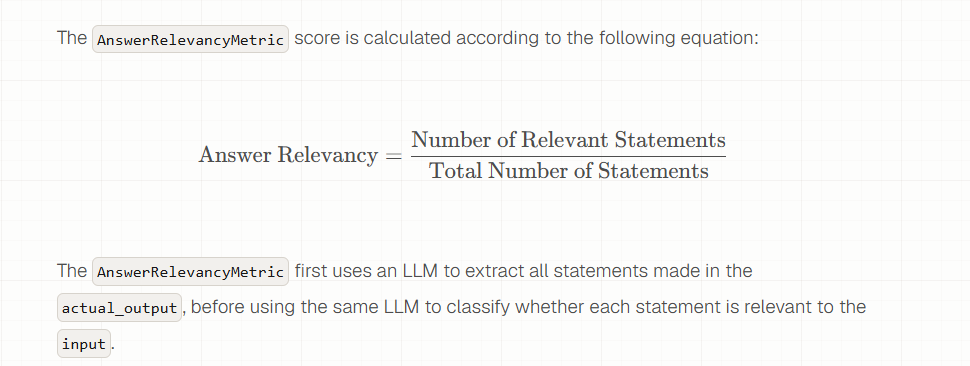

In [ ]:
import pandas as pd
import subprocess, sys

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'deepeval'])

from deepeval.metrics import AnswerRelevancyMetric
from deepeval.test_case import LLMTestCase
from google.colab import userdata
import os

os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

CSV_PATH = 'rag_eval.csv'
df       = pd.read_csv(CSV_PATH)

metric = AnswerRelevancyMetric(model='gpt-4o', include_reason=True)

scores, reasons = [], []
for i, row in df.iterrows():
    test_case = LLMTestCase(
        input             = row['query'],
        actual_output     = row['answer'],
        retrieval_context = [row['context_1'], row['context_2'], row['context_3']],
    )
    metric.measure(test_case)
    scores.append(metric.score)
    reasons.append(metric.reason)
    print(f'[{i+1:02d}/10]  score: {metric.score:.2f}  |  {metric.reason}')

df['answer_relevancy_score']  = scores
df['answer_relevancy_reason'] = reasons
df.to_csv(CSV_PATH, index=False)

pd.set_option('display.max_colwidth', 60)
df[['query', 'answer_relevancy_score', 'answer_relevancy_reason']].head(10)

## Contextual Relevancy (DeepEval)

Measures how relevant the retrieved context chunks are to the query — independent of the generated answer. A low score here means the retriever is surfacing the wrong chunks, which will hurt answer quality regardless of the LLM.

DeepEval's `ContextualRelevancyMetric` uses an LLM judge to score each retrieval on a scale of **0 to 1** and provides a reason explaining the score.

Docs: [deepeval.confident-ai.com/docs/metrics-contextual-relevancy](https://deepeval.com/docs/metrics-contextual-relevancy)

Results are appended as `contextual_relevancy_score` and `contextual_relevancy_reason` columns in the CSV.

Prompt Template: https://github.com/confident-ai/deepeval/blob/main/deepeval/metrics/contextual_relevancy/template.py

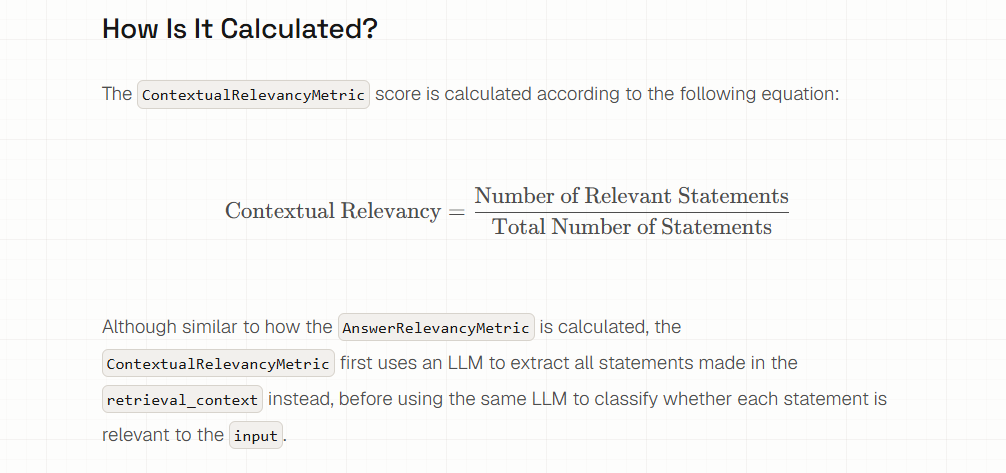

In [ ]:
from deepeval.metrics import ContextualRelevancyMetric
from deepeval.test_case import LLMTestCase

metric = ContextualRelevancyMetric(model='gpt-4o', include_reason=True)

scores, reasons = [], []
for i, row in df.iterrows():
    test_case = LLMTestCase(
        input             = row['query'],
        actual_output     = row['answer'],
        retrieval_context = [row['context_1'], row['context_2'], row['context_3']],
    )
    metric.measure(test_case)
    scores.append(metric.score)
    reasons.append(metric.reason)
    print(f'[{i+1:02d}/10]  score: {metric.score:.2f}  |  {metric.reason}')

df['contextual_relevancy_score']  = scores
df['contextual_relevancy_reason'] = reasons
df.to_csv(CSV_PATH, index=False)

pd.set_option('display.max_colwidth', 60)
df[['query', 'contextual_relevancy_score', 'contextual_relevancy_reason']].head(10)

## Faithfulness (DeepEval)

Measures whether the generated answer is factually grounded in the retrieved context — it detects hallucinations. A low score means the LLM is generating claims that are not supported by the retrieved chunks.

DeepEval's `FaithfulnessMetric` uses an LLM judge to score each answer on a scale of **0 to 1** and provides a reason explaining the score.

Docs: [deepeval.confident-ai.com/docs/metrics-faithfulness](https://deepeval.com/docs/metrics-faithfulness)

Results are appended as `faithfulness_score` and `faithfulness_reason` columns in the CSV.

Prompt Template: https://github.com/confident-ai/deepeval/blob/main/deepeval/metrics/faithfulness/template.py

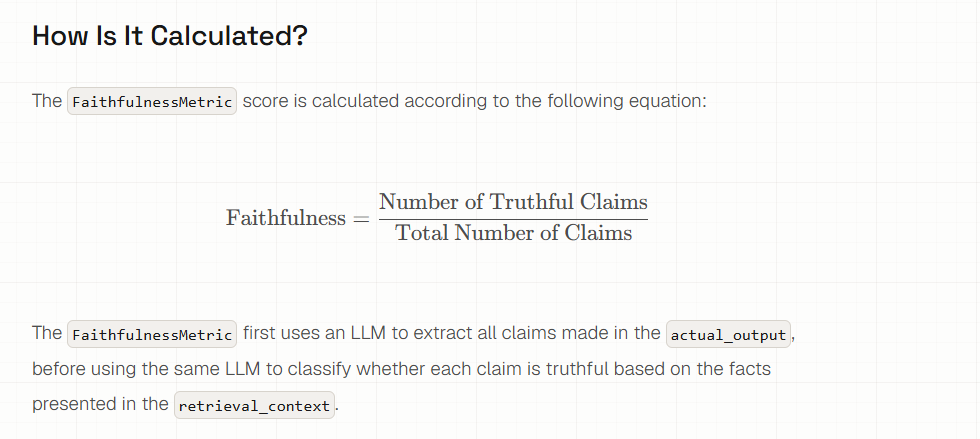

In [ ]:
import os
import pandas as pd
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get('openai_api')
os.environ['DEEPEVAL_PER_ATTEMPT_TIMEOUT_SECONDS_OVERRIDE'] = '120'

from deepeval.metrics import FaithfulnessMetric
from deepeval.test_case import LLMTestCase

CSV_PATH = 'rag_eval.csv'
df       = pd.read_csv(CSV_PATH)

MAX_CHARS = 1500

metric = FaithfulnessMetric(model='gpt-4o', include_reason=True)

scores, reasons = [], []
for i, row in df.iterrows():
    context = [
        str(row['context_1'])[:MAX_CHARS],
        str(row['context_2'])[:MAX_CHARS],
        str(row['context_3'])[:MAX_CHARS],
    ]
    test_case = LLMTestCase(
        input             = row['query'],
        actual_output     = row['answer'],
        retrieval_context = context,
    )
    metric.measure(test_case)
    scores.append(metric.score)
    reasons.append(metric.reason)
    print(f'[{i+1:02d}/10]  score: {metric.score:.2f}  |  {metric.reason}')

df['faithfulness_score']  = scores
df['faithfulness_reason'] = reasons
df.to_csv(CSV_PATH, index=False)

pd.set_option('display.max_colwidth', 60)
df[['query', 'faithfulness_score', 'faithfulness_reason']].head(10)

In [ ]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
df = pd.read_csv(CSV_PATH)
df.head(2)

## Prompt Improvement — Before vs After

The baseline prompt used in earlier cells is generic — it instructs the model to be concise and accurate, but provides no strict guardrails.

We now craft a **new prompt** with explicit constraints designed for RAG over research papers:

- **Explicit grounding** — the model is instructed to answer only from the provided context, not from its parametric knowledge
- **Faithfulness constraint** — fabricating numbers, equations, or results not present in the context is explicitly forbidden

This prompt is then used to re-run the same 10 queries, and the resulting answers are evaluated against the same DeepEval metrics — allowing a direct comparison between the baseline and the engineered prompt.

In [ ]:
BASELINE_SYSTEM_PROMPT = 'You are a research assistant. Answer the question using only the provided context. Be concise and precise.'

NEW_SYSTEM_PROMPT = """You are a precise research assistant specializing in AI/ML papers.

STRICT RULES:
1. Answer using information explicitly stated in the provided context.
2. If the context is partially relevant, use what is available and answer as completely as you can.
   Only say "The provided context does not cover this fully" if the context is entirely unrelated.
3. Do NOT add information from your general knowledge — only the context.
6. Never fabricate numbers, equations, or results not present in the context."""

print("BASELINE PROMPT:")
print("-"*60)
print(BASELINE_SYSTEM_PROMPT)
print()
print("NEW PROMPT:")
print("-"*60)
print(NEW_SYSTEM_PROMPT)

In [ ]:
client   = OpenAI(api_key=userdata.get('openai_api'))
CSV_PATH = 'rag_eval.csv'
df       = pd.read_csv(CSV_PATH)

print("Re-running with new prompt...\n")

new_results = []

for i, row in df.iterrows():
    query   = row['query']
    chunks  = [str(row['context_1']), str(row['context_2']), str(row['context_3'])]
    context = '\n\n'.join(chunks)

    response = client.chat.completions.create(
        model    = 'gpt-4o',
        messages = [
            {'role': 'system', 'content': NEW_SYSTEM_PROMPT},
            {'role': 'user',   'content': f'Context:\n{context}\n\nQuestion: {query}'}
        ]
    )
    answer = response.choices[0].message.content

    new_results.append({
        'question'        : query,
        'answer'          : answer,
        'retrieved_chunks': chunks,
    })

    print('=' * 70)
    print(f'Q{i+1}: {query}')
    print(f'  Answer: {answer}')
    print(f'\n  Retrieved (3 chunks):')

new_test_cases = [
    LLMTestCase(
        input             = r['question'],
        actual_output     = r['answer'],
        retrieval_context = r['retrieved_chunks'],
    )
    for r in new_results
]

print(f'Built {len(new_test_cases)} test cases with new prompt')

## Custom LLM-as-Judge · Contextual Relevancy Prompt

A domain-aware prompt designed specifically for RAG over AI/ML research papers.

Unlike DeepEval's generic contextual relevancy metric, this prompt explicitly tells the judge what counts as a relevant chunk in the context of research papers — technical details, architectural descriptions, experimental findings — and what does not — references, author affiliations, or generic background.

The prompt uses `{question}` and `{context}` as placeholders, filled at evaluation time in the next cell.

In [ ]:
CUSTOM_CONTEXTUAL_RELEVANCY_PROMPT = """You are an expert evaluator of RAG systems built over AI and ML research papers.

Your task is to assess whether the retrieved context chunks contain information
that is genuinely useful for answering a technical question about a research paper.

A chunk is considered relevant if it contains:
- The specific concept, method, or result the question is asking about
- Supporting technical detail such as equations, architecture descriptions, or experimental findings
- Direct discussion from the paper that addresses the question's intent

A chunk is NOT relevant if it contains:
- Only references, citations, or bibliography entries
- Unrelated sections such as author affiliations or acknowledgements
- Generic background that does not address the specific question

Question: {question}

Retrieved Context Chunks:
{context}

Based on the above, score how relevant the retrieved context is for answering the question.
Give a score between 0.0 and 1.0 and a one-sentence reason grounded in the content above.

Respond ONLY in this format:
Score: <score>
Reason: <one sentence>"""

print('CUSTOM_CONTEXTUAL_RELEVANCY_PROMPT defined.')

In [ ]:
import re
import pandas as pd
import os
from openai import OpenAI
from google.colab import userdata

os.environ['OPENAI_API_KEY'] = userdata.get('openai_api')
client   = OpenAI(api_key=userdata.get('openai_api'))
CSV_PATH = 'rag_eval.csv'
df       = pd.read_csv(CSV_PATH)

def custom_contextual_relevancy(question, chunks):
    context = '\n\n'.join(f'[Chunk {i+1}]: {c[:500]}' for i, c in enumerate(chunks))
    prompt  = CUSTOM_CONTEXTUAL_RELEVANCY_PROMPT.format(
        question=question,
        context=context,
    )
    resp   = client.chat.completions.create(
        model       = 'gpt-4o',
        messages    = [{'role': 'user', 'content': prompt}],
        temperature = 0.0,
        max_tokens  = 100,
    )
    output = resp.choices[0].message.content.strip()

    score, reason = 0.5, 'Parse error.'
    try:
        lines  = {l.split(':')[0].strip(): l.split(':', 1)[1].strip()
                  for l in output.split('\n') if ':' in l}
        score  = round(float(lines.get('Score', 0.5)), 3)
        reason = lines.get('Reason', '—')
    except (KeyError, ValueError):
        nums = re.findall(r'\d+\.\d+', output)
        if nums:
            score = round(float(nums[0]), 3)
    return score, reason


scores, reasons = [], []
for i, row in df.iterrows():
    chunks = [str(row['context_1']), str(row['context_2']), str(row['context_3'])]
    score, reason = custom_contextual_relevancy(row['query'], chunks)
    scores.append(score)
    reasons.append(reason)
    print(f'[{i+1:02d}/10]  score: {score:.2f}  |  {reason[:80]}')

df['custom_contextual_relevancy_score']  = scores
df['custom_contextual_relevancy_reason'] = reasons
df.to_csv(CSV_PATH, index=False)

pd.set_option('display.max_colwidth', 60)
df[['query', 'custom_contextual_relevancy_score', 'custom_contextual_relevancy_reason']].head(10)